# E8: Limits of generative distributional discrepancy

**Started:** January 28, 2026

**Last updated:** February 3, 2026

**Research question:** To what extent can the underlying source and target distributions vary before their alignment fails at the class level and sublabel level?

**Hypothesis:** When using anchoring methods, the underlying mean can vary by up to half of the mean distance between population centroids and the nearest population centroids. Standard deviation can vary from 0 to half the mean distance between nearest centroids (so variance can vary up to the square of that) before alignments fail.

**Conclusion:** Symmetry issues remain the dominant issue when moving distribution means. When there are not symmetry issues, both accuracy and sublabel accuracy are >=90% up to 40% of the the mean distance between nearest centroids when half of the dimensions are noise and half are discriminative.

**Potential Next Steps:** Explore effects of changing variance. Explore whether correlations within populations across dimensions helps prevent symmetry mismatch.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sp
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import ot
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from speciesot_simulation_helpers import generate_point_clouds, \
                              plot_first_two_dims, \
                              resample_point_clouds, \
                              flatten_clouds, \
                              run_ot, \
                              compute_mapping_acc, \
                              knn_geodesic_distance_matrix, \
                              plot_knn_graph, \
                              plot_got_best_matches_with_labels, \
                              gw_seeded, \
                              generate_point_clouds_subpops, \
                              resample_point_clouds_subpops, \
                              sublabel_match_rate_from_gw

In [2]:
import numpy as np

def resample_point_clouds_subpops(
    means, covs, P, seed=None,
    P_disc=0, SP=1, disc_pops=None,
    discriminative_strength=4,
    noise_dims=None,
    shared_noise_means=None,
    shared_noise_vars=None,
    mean_change=0.0,
    var_change=1.0
):
    """
    Resample clouds from stored means/covs, optionally re-imposing subpopulations,
    enforcing "noise dimensions" (shared mean/var), and *perturbing* non-noise
    population means and variances.

    New behavior (mean/var perturbation):
      - mean_change (float): magnitude factor. We compute
            mean_dist_between_pops = average (over populations) of the distance
            from each population mean to its nearest *other* population mean
            (computed only on non-noise dims).
        Then each population mean (on non-noise dims) is moved in a random
        direction whose length is (mean_change * mean_dist_between_pops).
      - var_change (float): multiplicative factor applied to *per-population*
        covariance submatrix on non-noise dims (i.e. multiply that submatrix by var_change).
        Noise-dim variances remain as specified by shared_noise_vars (or derived).

    Returns:
      clouds: (N, P, M)
      pop_labels: (N, P)
      subpop_labels: (N, P)
    """
    rng = np.random.default_rng(seed)

    means = np.asarray(means, float)
    covs = np.asarray(covs, float)

    N, M = means.shape
    if N == 0:
        return np.empty((0, P, M)), np.empty((0, P), dtype=int), np.empty((0, P), dtype=int)

    # sanitize inputs
    P_disc = int(min(max(int(P_disc), 0), M))
    SP = int(max(int(SP), 1))
    discriminative_strength = float(discriminative_strength)
    disc_dims = np.arange(P_disc)

    # disc_pops sanitization
    if disc_pops is None:
        disc_pops = np.arange(N, dtype=int)
    else:
        disc_pops = np.unique(np.asarray(disc_pops, dtype=int))
        disc_pops = disc_pops[(disc_pops >= 0) & (disc_pops < N)]
    disc_pops = np.sort(disc_pops)
    disc_set = set(disc_pops.tolist())

    # ---------- noise_dims handling (same logic as before) ----------
    if noise_dims is None:
        noise_dims_idx = np.array([], dtype=int)
    elif isinstance(noise_dims, (int, np.integer)):
        n_noise = int(noise_dims)
        if n_noise <= 0:
            noise_dims_idx = np.array([], dtype=int)
        else:
            start = P_disc
            available = np.arange(start, M)
            if n_noise > available.size:
                raise ValueError("Requested more noise_dims than available dimensions")
            noise_dims_idx = np.array(available[:n_noise], dtype=int)
    else:
        noise_dims_idx = np.unique(np.asarray(list(noise_dims), dtype=int))
        noise_dims_idx = noise_dims_idx[(noise_dims_idx >= 0) & (noise_dims_idx < M)]
        noise_dims_idx = noise_dims_idx[~np.isin(noise_dims_idx, disc_dims)]
    noise_dims_idx = np.sort(noise_dims_idx)
    n_noise = noise_dims_idx.size

    # derive shared noise means/vars if needed
    if n_noise > 0:
        if shared_noise_means is None:
            shared_noise_means = means[:, noise_dims_idx].mean(axis=0)
        else:
            shared_noise_means = np.asarray(shared_noise_means, float)
            if shared_noise_means.shape[0] != n_noise:
                raise ValueError("shared_noise_means length mismatch with noise_dims")
        if shared_noise_vars is None:
            per_pop_vars = np.asarray([np.diag(cov)[noise_dims_idx] for cov in covs])
            shared_noise_vars = per_pop_vars.mean(axis=0)
        else:
            shared_noise_vars = np.asarray(shared_noise_vars, float)
            if shared_noise_vars.shape[0] != n_noise:
                raise ValueError("shared_noise_vars length mismatch with noise_dims")
    else:
        shared_noise_means = np.array([], dtype=float)
        shared_noise_vars = np.array([], dtype=float)

    # Work on copies so inputs aren't mutated
    means_c = means.copy()
    covs_c = covs.copy()

    # enforce shared noise constraints first (so perturbation only affects non-noise dims)
    if n_noise > 0:
        for d_idx, d in enumerate(noise_dims_idx):
            means_c[:, d] = shared_noise_means[d_idx]
            for i in range(N):
                covs_c[i, d, :] = 0.0
                covs_c[i, :, d] = 0.0
                covs_c[i, d, d] = max(shared_noise_vars[d_idx], 1e-12)

    # ---------- compute mean_dist_between_pops as mean nearest-neighbor distance ----------
    other_dims = np.setdiff1d(np.arange(M), noise_dims_idx)
    if other_dims.size == 0 or N < 2:
        mean_dist_between_pops = 0.0
    else:
        means_other = means_c[:, other_dims]  # shape (N, D)
        # compute full pairwise distance matrix
        diff = means_other[:, None, :] - means_other[None, :, :]  # (N, N, D)
        dists = np.sqrt(np.sum(diff ** 2, axis=2))  # (N, N)
        # set diagonal to +inf so min excludes self
        np.fill_diagonal(dists, np.inf)
        # nearest-other distance for each population
        nearest = np.min(dists, axis=1)  # (N,)
        # average across populations
        mean_dist_between_pops = float(nearest.mean())

    # ---------- perturb means and variances on non-noise dims ----------
    if mean_dist_between_pops > 0 and mean_change != 0.0 and other_dims.size > 0:
        step = float(mean_change) * mean_dist_between_pops
        # for each population, pick a random direction in the subspace of other_dims
        for i in range(N):
            v = rng.standard_normal(other_dims.size)
            norm = np.linalg.norm(v)
            if norm <= 0:
                continue
            v_unit = v / norm
            means_c[i, other_dims] += step * v_unit

    # multiply non-noise covariance submatrices by var_change
    if var_change != 1.0 and other_dims.size > 0:
        for i in range(N):
            idx = np.ix_(other_dims, other_dims)
            covs_c[i][idx] = covs_c[i][idx] * float(var_change)
            # cross-covariances with noise dims remain zero (set earlier)

    # ---------- now resample using means_c and covs_c, similar to previous implementation ----------
    clouds = np.empty((N, P, M))
    pop_labels = np.repeat(np.arange(N)[:, None], P, axis=1)
    subpop_labels = np.zeros((N, P), dtype=int)

    # reference population and bias dim, for signed bias
    non_disc = [j for j in range(N) if j not in disc_set]
    ref_pop = non_disc[0] if non_disc else None
    bias_dim = P_disc if P_disc < M else None

    use_subpops = (P_disc > 0) and (SP > 1)

    for i in range(N):
        L = np.linalg.cholesky(covs_c[i])
        Z = rng.standard_normal((P, M))
        base = means_c[i] + Z @ L.T

        if use_subpops and (i in disc_set):
            sub = (np.arange(P) % SP) + 1
            rng.shuffle(sub)
            subpop_labels[i] = sub

            std = np.sqrt(np.diag(covs_c[i]))
            centers = (sub - (SP + 1) / 2.0)
            offsets = np.zeros((P, M))
            offsets[:, disc_dims] = centers[:, None] * (discriminative_strength * std[disc_dims])[None, :]

            if (ref_pop is not None) and (bias_dim is not None):
                delta = means_c[ref_pop, bias_dim] - means_c[i, bias_dim]
                sign = 1.0 if delta >= 0 else -1.0
                offsets[sub == 1, bias_dim] += sign * discriminative_strength * std[bias_dim]

            clouds[i] = base + offsets
        else:
            clouds[i] = base

    return clouds, pop_labels, subpop_labels


In [51]:
num_clouds = 5
num_points_per_cloud = 20
num_dims = 2
num_disc_dims=2
num_noise_dims=0

In [52]:
clouds1, means1, covs1, poplabels1, sublabels1 = generate_point_clouds_subpops(num_clouds, 
                                                                               num_points_per_cloud, 
                                                                               num_dims, 
                                                                               A=2, 
                                                                               B=0.5, 
                                                                               P_disc=num_disc_dims, 
                                                                               SP=2, 
                                                                               disc_pops=[0],
                                                                               discriminative_strength=2,
                                                                               noise_dims=num_noise_dims)

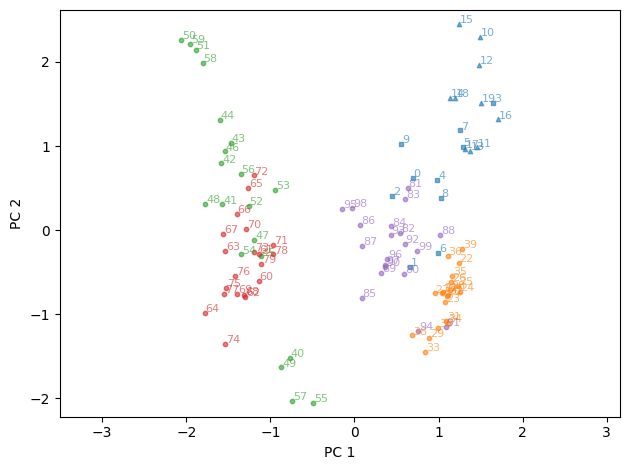

In [53]:
plot_first_two_dims(clouds1, sublabels=sublabels1, annotate=True, pca=True)

In [54]:
clouds2, poplabels2, sublabels2 = resample_point_clouds_subpops(means1, covs1, num_points_per_cloud,
    P_disc=10, SP=2, disc_pops=[0],
    discriminative_strength=2,
    mean_change=0.5,
    var_change=1.0)

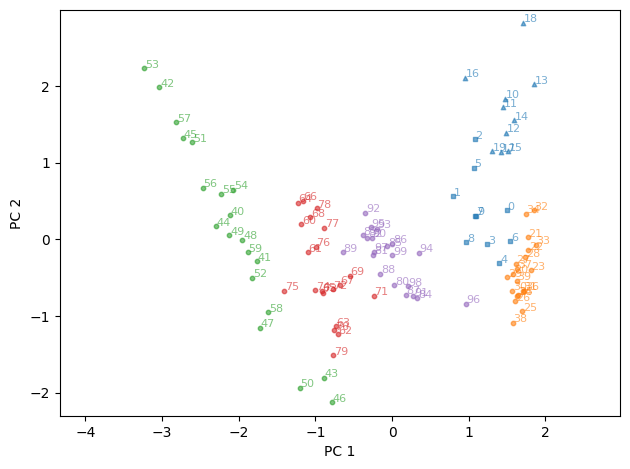

In [55]:
plot_first_two_dims(clouds2, sublabels=sublabels2, annotate=True, pca=True)

In [56]:
cloud_coords1, labels1 = flatten_clouds(clouds1)
cloud_coords2, labels2 = flatten_clouds(clouds2)

In [57]:
gws = gw_seeded(cloud_coords1, cloud_coords2, num_clouds * num_points_per_cloud, [50], [53], distance_method="euclidean")

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>,
 array([ 5, 10, 12, 32,  3,  6, 84, 15, 95,  1,  7, 18,  0, 11,  8,  4,  2,
        14, 19, 92, 39, 29, 21, 30, 23, 33, 28,  9, 27, 25, 24, 31, 37, 38,
        36, 22, 13, 29, 96, 34, 62, 49, 54, 56, 51, 67, 55, 77, 44, 79, 53,
        57, 68, 78, 61, 46, 40, 43, 45, 42, 73, 65, 70, 41, 47, 64, 48, 59,
        63, 74, 60, 89, 66, 76, 50, 52, 75, 58, 69, 72, 91, 93, 99, 86, 85,
        71, 90, 81, 16, 87, 98, 36, 94, 99, 26, 83, 88, 80, 82, 17]),
 array([0.00999301, 0.00937158, 0.00998694, 0.00998417, 0.01      ,
        0.00996452, 0.00664062, 0.01      , 0.00639217, 0.00993521,
        0.00999136, 0.00371638, 0.00984893, 0.00628071, 0.00999864,
        0.00995991, 0.00991965, 0.0062039 , 0.00545319, 0.00996143,
        0.00557618, 0.00372098, 0.00991997, 0.00912764, 0.00842818,
        0.00824391, 0.00607563, 0.00935275, 0.00478108, 0.00990856,
  

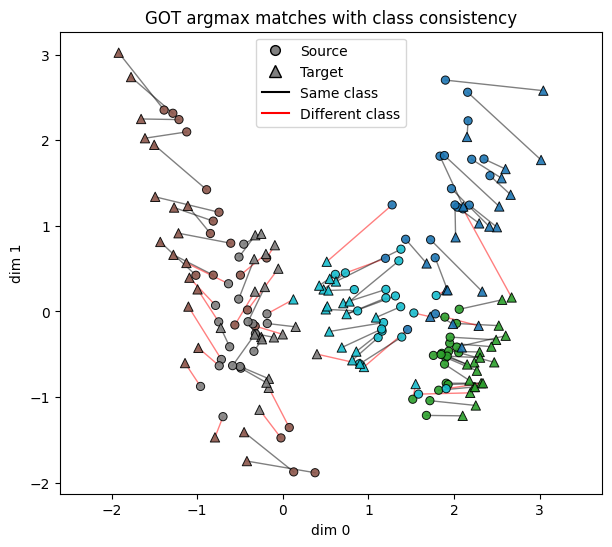

In [58]:
plot_got_best_matches_with_labels(cloud_coords1, cloud_coords2, gws, labels1, labels2)

In [59]:
compute_mapping_acc(gws, labels1, labels2)

0.73

In [60]:
sublabel_match_rate_from_gw(gws, labels1, labels2, sublabels1, sublabels2)

0.65

### Simulate moving distributions

Only move distributions that do not have a symmetry mathing issue by default.

In [14]:
def plot_mean_std(df, x="cloud size", y="accuracy"):
    stats = df.groupby(x)[y].agg(["mean", "std"]).reset_index()

    plt.plot(stats[x], stats["mean"], marker="o")
    plt.fill_between(
        stats[x],
        stats["mean"] - stats["std"],
        stats["mean"] + stats["std"],
        alpha=0.3
    )

    #plt.xlabel(x)
    #plt.ylabel(y)
    plt.tight_layout()
    plt.show()

In [17]:
num_clouds = 5
num_points_per_cloud = 20
num_dims = 50
num_disc_dims=25
num_noise_dims=25

In [22]:
mean_mvt_arr = []
mean_mvt_acc_arr = []
mean_mvt_sublabel_acc_arr = []
for distance_method in ['euclidean']:
    for mean_mvt in [0,0.05,0.1,0.15,0.2,0.5,1.0]:
        non_flipping_examples = 0
        while non_flipping_examples < 5:
            clouds1, means1, covs1, poplabels1, sublabels1 = generate_point_clouds_subpops(num_clouds, 
                                                                                       num_points_per_cloud, 
                                                                                       num_dims, 
                                                                                       A=2, 
                                                                                       B=0.5, 
                                                                                       P_disc=num_disc_dims, 
                                                                                       SP=2, 
                                                                                       disc_pops=[0],
                                                                                       discriminative_strength=2,
                                                                                       noise_dims=num_noise_dims)
            clouds2, poplabels2, sublabels2 = resample_point_clouds_subpops(means1, covs1, num_points_per_cloud,
                                                                    P_disc=num_disc_dims, SP=2, disc_pops=[0],
                                                                    discriminative_strength=2,
                                                                    noise_dims=num_noise_dims)
            cloud_coords1, labels1 = flatten_clouds(clouds1)
            cloud_coords2, labels2 = flatten_clouds(clouds2)

            gw = run_ot(cloud_coords1, cloud_coords2, num_clouds * num_points_per_cloud, 
                        distance_method=distance_method)

            acc = compute_mapping_acc(gw, labels1, labels2)

            print(acc)

            if acc > 0.7:
                non_flipping_examples += 1
                
                clouds3, poplabels3, sublabels3 = resample_point_clouds_subpops(means1, covs1, num_points_per_cloud,
                                                        P_disc=num_disc_dims, SP=2, disc_pops=[0],
                                                        discriminative_strength=2,
                                                        noise_dims=num_noise_dims,
                                                        mean_change=mean_mvt)
                cloud_coords3, labels3 = flatten_clouds(clouds3)

                gw_mvt = run_ot(cloud_coords1, cloud_coords3, num_clouds * num_points_per_cloud, 
                        distance_method="euclidean")

                acc_mvt = compute_mapping_acc(gw_mvt, labels1, labels3)

                sublabel_acc_mvt = sublabel_match_rate_from_gw(gw_mvt, labels1, labels3, sublabels1, sublabels3)

                mean_mvt_arr.append(mean_mvt)
                mean_mvt_acc_arr.append(acc_mvt)
                mean_mvt_sublabel_acc_arr.append(sublabel_acc_mvt)
    

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


1.0
0.2
1.0
1.0
1.0
0.2
0.8
1.0
1.0
1.0
0.19
0.98
1.0
1.0
1.0
0.6
0.98
1.0
1.0
0.4
1.0
0.96
0.6
1.0
1.0
1.0
1.0
0.6
1.0
0.6
1.0
1.0
1.0
1.0
1.0
0.6
0.6
0.6
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.6
1.0


In [23]:
moving_distributions_df = pd.DataFrame([mean_mvt_arr, mean_mvt_acc_arr, mean_mvt_sublabel_acc_arr]).T
moving_distributions_df.columns = ['mean_movement', 'accuracy', 'sublabel_accuracy']
moving_distributions_df.to_csv('data/moving_dists_sublabel_accuracy_012925.csv')

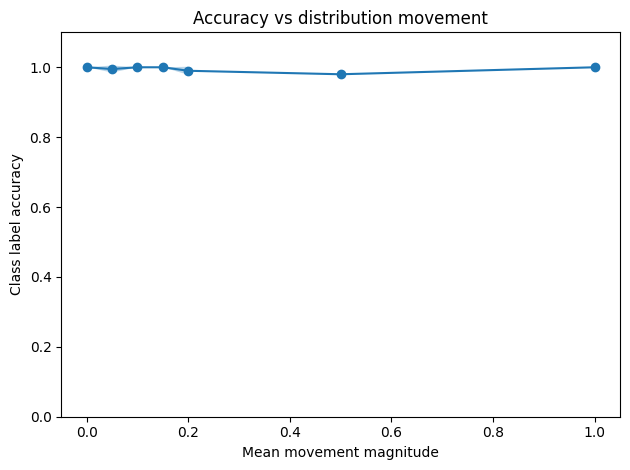

In [28]:
plt.title("Accuracy vs distribution movement")
plt.xlabel("Mean movement magnitude")
plt.ylabel("Class label accuracy")
plt.ylim([0,1.1])
plot_mean_std(moving_distributions_df[moving_distributions_df['accuracy']>0.7], x='mean_movement', y='accuracy')

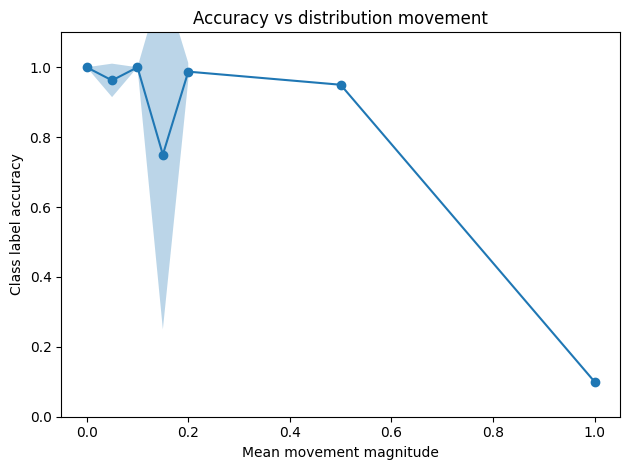

In [29]:
plt.title("Accuracy vs distribution movement")
plt.xlabel("Mean movement magnitude")
plt.ylabel("Class label accuracy")
plt.ylim([0,1.1])
plot_mean_std(moving_distributions_df[moving_distributions_df['accuracy']>0.7], x='mean_movement', y='sublabel_accuracy')

In [27]:
moving_distributions_df[moving_distributions_df['accuracy']>0.7]

,mean_movement,accuracy,sublabel_accuracy
1,0.00,1.00,1.00
2,0.00,1.00,1.00
5,0.05,1.00,1.00
7,0.05,1.00,0.90
8,0.05,0.98,0.95
9,0.05,1.00,1.00
10,0.10,1.00,1.00
11,0.10,1.00,1.00
13,0.10,1.00,1.00
14,0.10,1.00,1.00


(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>,
 array([18, 13, 10,  3, 12, 16, 17,  7, 11,  6, 15,  9,  2,  0,  8, 14, 19,
         4,  1,  5, 64, 62, 79, 73, 78, 74, 69, 72, 61, 70, 76, 68, 71, 66,
        77, 63, 60, 65, 67, 75, 47, 55, 53, 56, 45, 40, 46, 48, 52, 41, 42,
        44, 59, 51, 58, 54, 49, 43, 50, 57, 25, 34, 33, 26, 20, 35, 32, 28,
        38, 21, 36, 37, 27, 23, 29, 39, 22, 31, 30, 24, 87, 84, 90, 89, 99,
        91, 94, 83, 82, 96, 80, 98, 88, 86, 97, 85, 95, 92, 81, 93]),
 array([0.00999963, 0.00999949, 0.01      , 0.01      , 0.00999618,
        0.00999723, 0.00999915, 0.00999961, 0.01      , 0.00999695,
        0.01      , 0.00999993, 0.00999967, 0.00999933, 0.00999912,
        0.01      , 0.00999944, 0.01      , 0.01      , 0.00999916,
        0.01      , 0.01      , 0.00999978, 0.01      , 0.01      ,
        0.01      , 0.01      , 0.00999967, 0.00999989, 0.00999983,
  

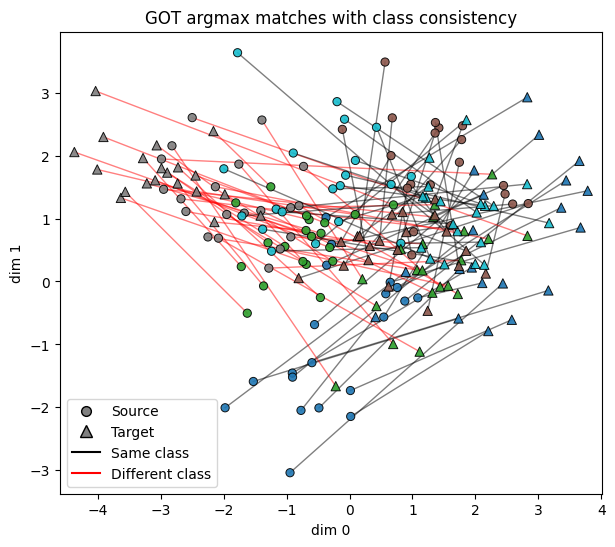

In [30]:
plot_got_best_matches_with_labels(cloud_coords1, cloud_coords3, gw_mvt, labels1, labels3)

Next, investigate whether maintaining same sample, just changing mean, will keep flipping from occurring.

Step 1: Make 5 cloud pairs with no motion, select 5 anchors each (1 per population).

Step 2: Increasingly move the means of the target distributions without changing the sampling (just the mean).

In [37]:
def perturb_clouds_like_resample(
    clouds, pop_labels, subpop_labels,
    means, covs,
    mean_change=0.0, var_change=1.0,
    noise_dims=None,
    seed=None,
    eps=1e-12
):
    """
    Perturb an existing `clouds` array in-place style (returns a new array) to match the
    *same kind* of constant mean/variance changes as the updated resample_point_clouds:

    1) Compute mean_dist_between_pops = mean over populations of (distance from each
       population centroid to its nearest other population centroid), using ONLY
       non-noise dimensions.
    2) For each population i, choose a random direction (in non-noise dims) and shift
       *all its points* by a constant vector of magnitude:
            step = mean_change * mean_dist_between_pops
    3) Multiply the within-population covariance (in non-noise dims) by var_change by
       scaling deviations-from-pop-mean by sqrt(var_change).
       (This is the correct way to scale variance; multiplying deviations by sqrt(c)
        multiplies covariance by c.)

    Inputs:
      clouds: (N, P, M) points (e.g., from resample_point_clouds)
      pop_labels: (N, P) population labels (each row typically all i)
      subpop_labels: (N, P) subpop labels (not used here, included for compatibility)
      means: (N, M) original population means (e.g., from generate_point_clouds_subpops)
      covs: (N, M, M) original covariances (not strictly required for the perturbation;
            included to mirror signature / future extensions)
      mean_change: float, magnitude multiplier for mean shifts
      var_change: float, multiplicative factor for variances (covariance)
      noise_dims: None, int, or iterable of indices; excluded from perturbation
      seed: random seed for choosing random shift directions
      eps: small value to avoid numerical issues

    Returns:
      clouds_new: (N, P, M) perturbed clouds
    """
    rng = np.random.default_rng(seed)

    clouds = np.asarray(clouds, float)
    means = np.asarray(means, float)
    covs = np.asarray(covs, float)  # kept for API symmetry; not used directly

    if clouds.ndim != 3:
        raise ValueError("clouds must have shape (N, P, M)")
    N, P, M = clouds.shape
    if means.shape != (N, M):
        raise ValueError(f"means must have shape (N, M) = ({N}, {M})")
    if covs.shape != (N, M, M):
        raise ValueError(f"covs must have shape (N, M, M) = ({N}, {M}, {M})")

    # -------- noise_dims -> indices --------
    if noise_dims is None:
        noise_dims_idx = np.array([], dtype=int)
    elif isinstance(noise_dims, (int, np.integer)):
        n_noise = int(noise_dims)
        if n_noise <= 0:
            noise_dims_idx = np.array([], dtype=int)
        else:
            if n_noise > M:
                raise ValueError("noise_dims int exceeds M")
            noise_dims_idx = np.arange(n_noise, dtype=int)
    else:
        noise_dims_idx = np.unique(np.asarray(list(noise_dims), dtype=int))
        noise_dims_idx = noise_dims_idx[(noise_dims_idx >= 0) & (noise_dims_idx < M)]
    noise_dims_idx = np.sort(noise_dims_idx)

    other_dims = np.setdiff1d(np.arange(M), noise_dims_idx)

    # If nothing to perturb, return a copy
    if other_dims.size == 0 or (abs(mean_change) <= eps and abs(var_change - 1.0) <= eps):
        return clouds.copy()

    # -------- mean_dist_between_pops using nearest-neighbor distances between means --------
    if N < 2:
        mean_dist_between_pops = 0.0
    else:
        means_other = means[:, other_dims]  # (N, D)
        diff = means_other[:, None, :] - means_other[None, :, :]
        dists = np.sqrt(np.sum(diff ** 2, axis=2))
        np.fill_diagonal(dists, np.inf)
        nearest = np.min(dists, axis=1)
        mean_dist_between_pops = float(nearest.mean())

    step = float(mean_change) * mean_dist_between_pops

    # -------- build per-pop shift vectors and apply variance scaling --------
    clouds_new = clouds.copy()

    # variance scaling factor to achieve cov *= var_change
    if var_change < 0:
        raise ValueError("var_change must be non-negative")
    scale = float(np.sqrt(var_change))

    # We'll identify which points belong to which population using pop_labels.
    # Expectation: pop_labels contains integers 0..N-1. We'll handle general cases too.
    pop_labels = np.asarray(pop_labels)
    if pop_labels.shape != (N, P):
        raise ValueError("pop_labels must have shape (N, P) matching clouds")

    # For each population id, perturb all points with that label.
    # (Usually that's exactly row i, but this is robust.)
    for pop_id in np.unique(pop_labels):
        mask = (pop_labels == pop_id)
        if not np.any(mask):
            continue

        # indices where mask is True: (row_idx, point_idx)
        rows, cols = np.where(mask)

        # compute the empirical centroid of this population in the current clouds
        pts = clouds_new[rows, cols, :]  # (#pts, M)
        mu = pts.mean(axis=0)

        # 1) scale deviations in other_dims to adjust variance
        if abs(var_change - 1.0) > eps:
            dev = pts[:, other_dims] - mu[other_dims]
            pts[:, other_dims] = mu[other_dims] + scale * dev

        # 2) add mean shift in a random direction in other_dims
        if abs(step) > eps:
            v = rng.standard_normal(other_dims.size)
            norm = np.linalg.norm(v)
            if norm > eps:
                v_unit = v / norm
                pts[:, other_dims] += step * v_unit

        # write back
        clouds_new[rows, cols, :] = pts

    return clouds_new


In [31]:
num_clouds = 5
num_points_per_cloud = 20
num_dims = 50
num_disc_dims=25
num_noise_dims=25

In [33]:
clouds1_list = []
means1_list = []
covs1_list = []
poplabels1_list = []
sublabels1_list = []
clouds2_list = []
poplabels2_list = []
sublabels2_list = []

In [59]:
range(num_noise_dims,num_dims)

range(25, 50)

cloud1, 0


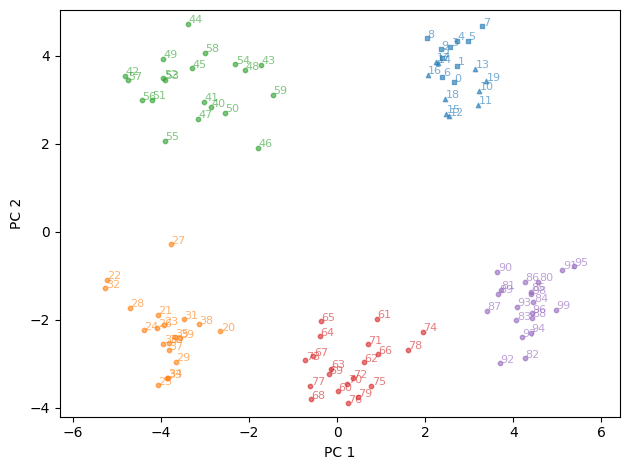

cloud2, 0


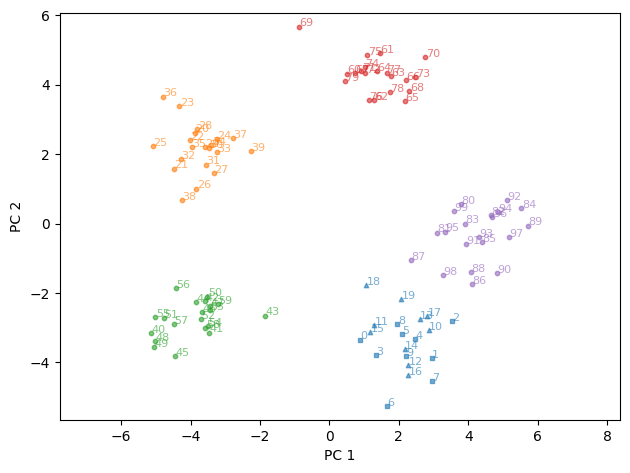

cloud1, 1


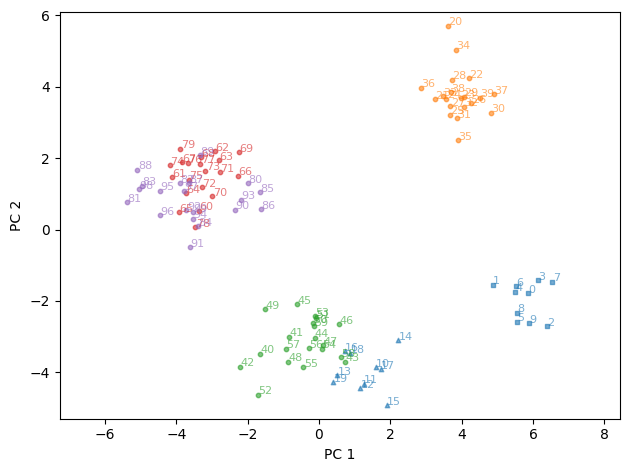

cloud2, 1


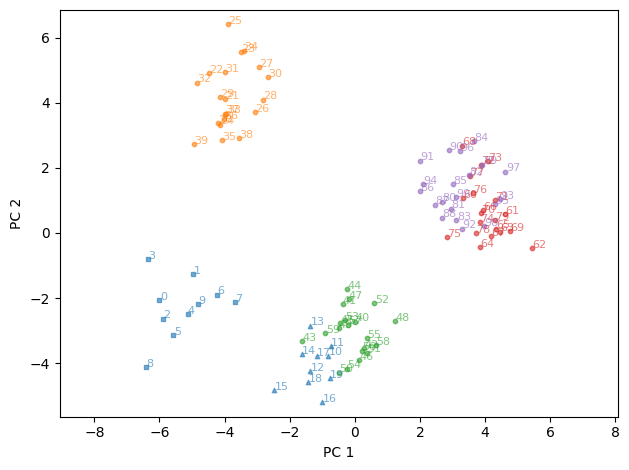

cloud1, 2


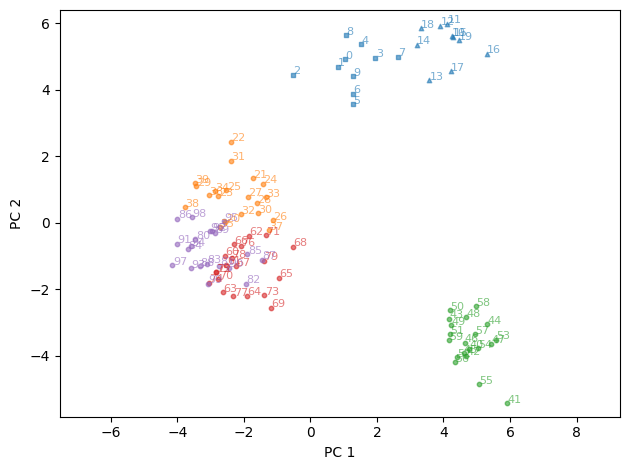

cloud2, 2


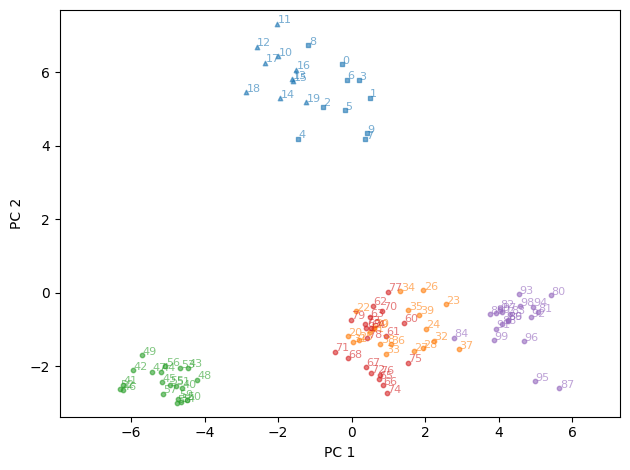

In [63]:
for i in range(3):
    clouds1, means1, covs1, poplabels1, sublabels1 = generate_point_clouds_subpops(num_clouds, 
                                                                               num_points_per_cloud, 
                                                                               num_dims, 
                                                                               A=2, 
                                                                               B=0.5, 
                                                                               P_disc=num_disc_dims, 
                                                                               SP=2, 
                                                                               disc_pops=[0],
                                                                               discriminative_strength=2,
                                                                               noise_dims=num_noise_dims)
    clouds2, poplabels2, sublabels2 = resample_point_clouds_subpops(means1, covs1, num_points_per_cloud,
                                                            P_disc=num_disc_dims, SP=2, disc_pops=[0],
                                                            discriminative_strength=2,
                                                            noise_dims=num_noise_dims)
    cloud_coords1, labels1 = flatten_clouds(clouds1)
    cloud_coords2, labels2 = flatten_clouds(clouds2)

    clouds1_list.append(clouds1)
    means1_list.append(means1)
    covs1_list.append(covs1)
    poplabels1_list.append(poplabels1)
    sublabels1_list.append(sublabels1)
    clouds2_list.append(clouds2)
    poplabels2_list.append(poplabels2)
    sublabels2_list.append(sublabels2)

    print("cloud1, " + str(i))
    plot_first_two_dims(clouds1, sublabels=sublabels1, annotate=True, pca=True)

    print("cloud2, " + str(i))
    plot_first_two_dims(clouds2, sublabels=sublabels2, annotate=True, pca=True)
    

In [64]:
anchors1 = [[44, 27, 74, 90],
            [20, 69, 42, 81],
            [50, 97, 69, 38]
            ]
anchors2 = [[45, 38, 65, 87],
           [25, 68, 48, 97],
           [48, 87, 71, 37]
            ]

In [66]:
mean_mvt_arr = []
mean_mvt_acc_arr = []
mean_mvt_sublabel_acc_arr = []
for distance_method in ['euclidean']:
    for i in range(3):
        for mean_mvt in [0,0.1,0.2,0.3,0.4,0.5,1.0]:
    
            clouds3 = perturb_clouds_like_resample(clouds2_list[i], poplabels2_list[i], sublabels2_list[i], 
                                         means1_list[i], covs1_list[i],
                                         mean_change=mean_mvt, noise_dims=range(num_noise_dims,num_dims))
            cloud_coords1, labels1 = flatten_clouds(clouds1_list[i])
            cloud_coords3, labels3 = flatten_clouds(clouds3)
    
            gw_mvt = gw_seeded(cloud_coords1, cloud_coords3, num_clouds * num_points_per_cloud, anchors1[i], anchors2[i],
                    distance_method="euclidean")
    
            acc_mvt = compute_mapping_acc(gw_mvt, labels1, labels3)
    
            sublabel_acc_mvt = sublabel_match_rate_from_gw(gw_mvt, labels1, labels3, 
                                                           sublabels1_list[i], sublabels2_list[i])
    
            mean_mvt_arr.append(mean_mvt)
            mean_mvt_acc_arr.append(acc_mvt)
            mean_mvt_sublabel_acc_arr.append(sublabel_acc_mvt)

            print(i, mean_mvt, acc_mvt, sublabel_acc_mvt)
    

0 0 1.0 0.9
0 0.1 1.0 0.9
0 0.2 1.0 0.9
0 0.3 1.0 0.9
0 0.4 1.0 1.0
0 0.5 0.4 0.0
0 1.0 0.0 0.0
1 0 1.0 1.0
1 0.1 1.0 1.0
1 0.2 1.0 1.0
1 0.3 1.0 0.9
1 0.4 1.0 1.0
1 0.5 1.0 1.0
1 1.0 1.0 0.9
2 0 1.0 1.0
2 0.1 1.0 1.0
2 0.2 1.0 1.0
2 0.3 1.0 1.0
2 0.4 1.0 1.0
2 0.5 1.0 1.0
2 1.0 1.0 1.0


(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>,
 array([ 0, 17, 15, 13, 12,  4,  3, 10,  1, 18,  2, 19, 14,  9, 16,  5,  6,
         7,  8, 11, 25, 24, 29, 23, 35, 31, 37, 21, 20, 30, 27, 36, 38, 22,
        34, 33, 32, 28, 26, 39, 45, 46, 50, 55, 43, 54, 58, 44, 49, 42, 48,
        59, 41, 51, 40, 47, 57, 53, 56, 52, 65, 72, 78, 66, 79, 64, 74, 75,
        63, 71, 60, 77, 76, 70, 69, 61, 73, 67, 68, 62, 94, 80, 83, 86, 98,
        82, 88, 99, 85, 92, 96, 97, 84, 95, 81, 89, 91, 87, 93, 90]),
 array([0.01      , 0.00999975, 0.00999968, 0.01      , 0.00999985,
        0.00999987, 0.01      , 0.01      , 0.01      , 0.01      ,
        0.01      , 0.01      , 0.00999999, 0.01      , 0.01      ,
        0.01      , 0.01      , 0.01      , 0.01      , 0.00999986,
        0.01      , 0.01      , 0.00999972, 0.00999982, 0.00999979,
        0.01      , 0.00999981, 0.01      , 0.01      , 0.00999992,
  

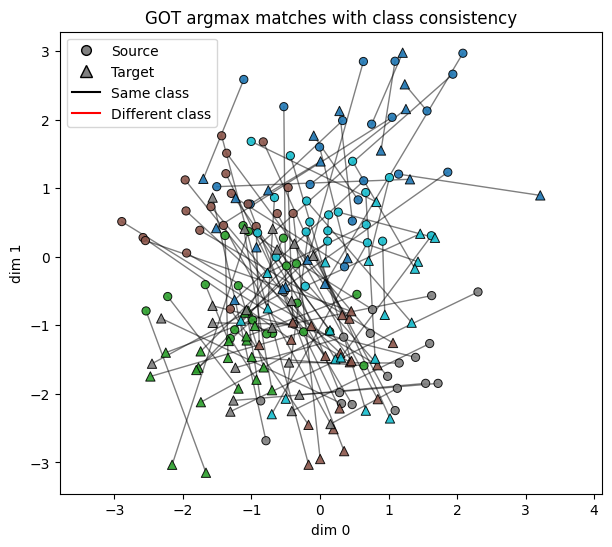

In [67]:
plot_got_best_matches_with_labels(cloud_coords1, cloud_coords2, gw_mvt, labels1, labels3)

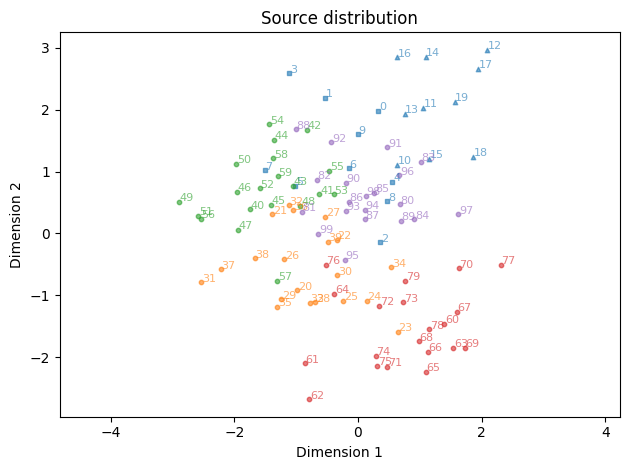

In [77]:
plt.title("Source distribution")
plot_first_two_dims(clouds1_list[i], sublabels=sublabels1_list[i], annotate=True)

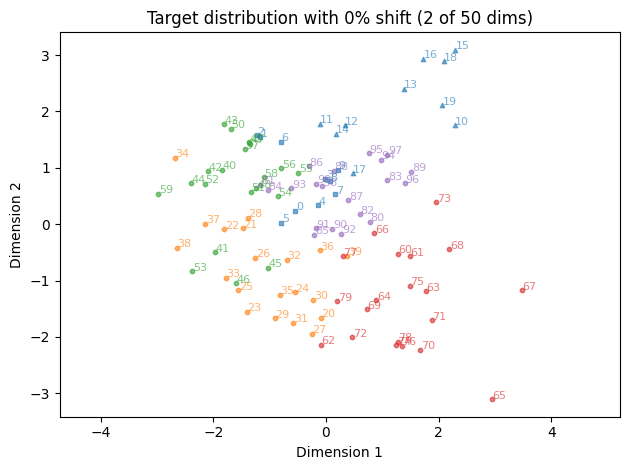

In [81]:
plt.title("Target distribution with 0% shift (2 of 50 dims)")
plot_first_two_dims(clouds2_list[i], sublabels=sublabels2_list[i], annotate=True)

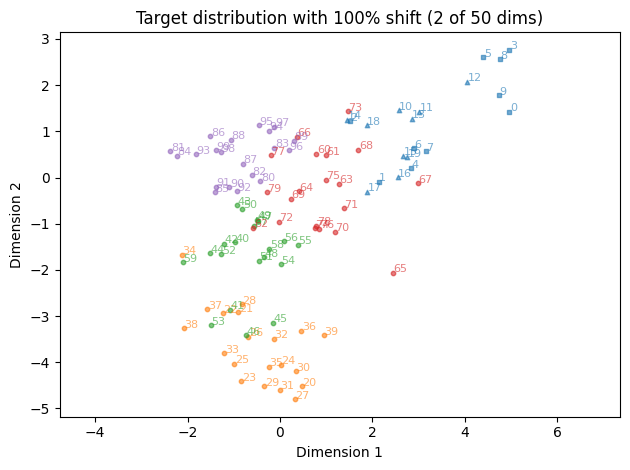

In [80]:
plt.title("Target distribution with 100% shift (2 of 50 dims)")
plot_first_two_dims(clouds3, sublabels=sublabels3, annotate=True)

In [82]:
clouds3 = perturb_clouds_like_resample(clouds2_list[i], poplabels2_list[i], sublabels2_list[i], 
                                         means1_list[i], covs1_list[i],
                                         mean_change=0.4, noise_dims=range(num_noise_dims,num_dims))

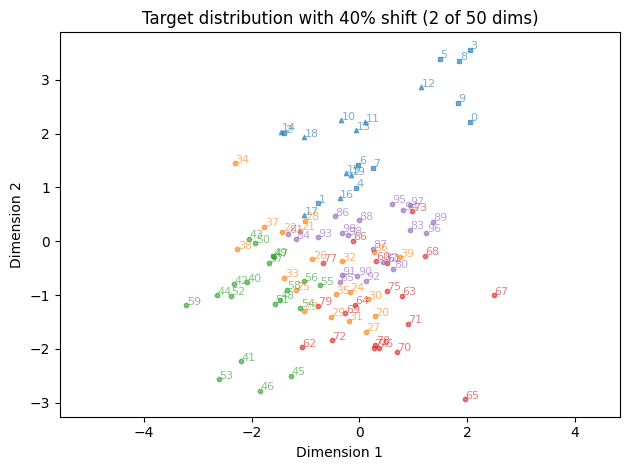

In [83]:
plt.title("Target distribution with 40% shift (2 of 50 dims)")
plot_first_two_dims(clouds3, sublabels=sublabels3, annotate=True)

In [70]:
moving_distributions_df = pd.DataFrame([mean_mvt_arr, mean_mvt_acc_arr, mean_mvt_sublabel_acc_arr]).T
moving_distributions_df.columns = ['mean_movement', 'accuracy', 'sublabel_accuracy']
moving_distributions_df.to_csv('data/moving_dists_shifted_sublabel_accuracy_012925.csv')

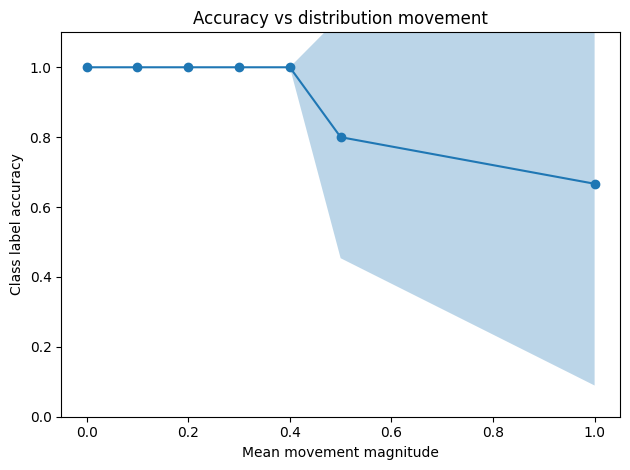

In [72]:
plt.title("Accuracy vs distribution movement")
plt.xlabel("Mean movement magnitude")
plt.ylabel("Class label accuracy")
plt.ylim([0,1.1])
plot_mean_std(moving_distributions_df, x='mean_movement', y='accuracy')

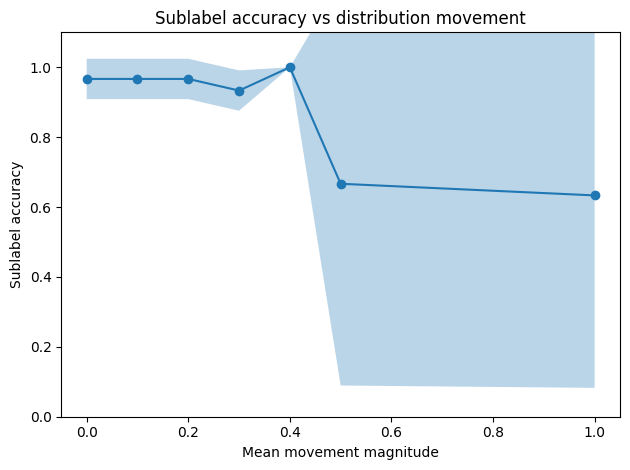

In [73]:
plt.title("Sublabel accuracy vs distribution movement")
plt.xlabel("Mean movement magnitude")
plt.ylabel("Sublabel accuracy")
plt.ylim([0,1.1])
plot_mean_std(moving_distributions_df, x='mean_movement', y='sublabel_accuracy')

In [74]:
! pwd

28117.66s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT
